In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path

root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))
print("Setting root of the project to:", root)
print("This means we can bring in models from other directories (like ./models)")

Setting root of the project to: /home/kv/education/predicting_DFE
This means we can bring in models from other directories (like ./models)


In [29]:

# Read a single allele frequency, i.e., "0:200:0:1:0:0"
def alleleFrequency(base, allele_count):
    # Allele count format: [A : T : C : G : N : del]
    base_dict = {
        'A': 0,
        'T': 1,
        'C': 2,
        'G': 3,
        'N': 4,   # unused
        'del': 5  # unsued, both defined to be explicit
    }
    base_index = base_dict.get(base)
    vector = [int(num) for num in allele_count.split(':')]

    # Sum all values
    total = sum(vector)

    # Error-handle for division-by-zero
    if total == 0:
        return 0.0

    # Find difference between base & total
    base_value = vector[base_index]
    mutations = total - base_value
    freq = mutations / total
    return freq;


In [85]:
columns = [
    'chromosome',
    'position',
    'base',
    'Dsim_Fl_Base_1',
    'Dsim_Fl_Hot_F10_1',
    'Dsim_Fl_Hot_F20_1', 
    'Dsim_Fl_Hot_F30_1',
    'Dsim_Fl_Hot_F40_1', 
    'Dsim_Fl_Hot_F50_1', 
    'Dsim_Fl_Hot_F60_1'
]

df = pd.read_csv(
    filepath_or_buffer="../data/chromosome_2L.sync",
    sep='\t', # tab-separated values
    names=columns,
    usecols=columns,
    header=None # no headers provided
)

rename_dict = {
    'Dsim_Fl_Base_1':    'count_t0',
    'Dsim_Fl_Hot_F10_1': 'count_t10',
    'Dsim_Fl_Hot_F20_1': 'count_t20',
    'Dsim_Fl_Hot_F30_1': 'count_t30',
    'Dsim_Fl_Hot_F40_1': 'count_t40',
    'Dsim_Fl_Hot_F50_1': 'count_t50',
    'Dsim_Fl_Hot_F60_1': 'count_t60'
}

# Rename the columns (inplace=True modifies the original DataFrame)
df.drop(columns=['chromosome'], inplace=True)
df.rename(columns=rename_dict, inplace=True)


# Generate the totals and allele frequencies from the allele counts
for generation in ['0','10','20','30','40','50','60']:
    df[f'freq_t{generation}'] = [
        alleleFrequency(b, c) 
        for b, c in zip(df['base'], df[f'count_t{generation}'])
    ]
    df[f'total_t{generation}'] = [
        sum(int(num) for num in allele_count.split(':'))
        for allele_count in df[f'count_t{generation}']
    ]

# Generate the change in allele frequencies
for generation in [10,20,30,40,50,60]:
    prev_generation = generation - 10
    df[f'delta_t{generation}'] = df[f'freq_t{generation}'] - df[f'freq_t{prev_generation}']

# Pick 70,000 positions - trivially start from the 1st position over 1,000,000
starting_index = df[df.position > 1_000_000].index[0]
starting_loc = df.index.get_loc(starting_index)
df = df.iloc[starting_loc : starting_loc + 70_000]

In [31]:
df.head()

,position,base,count_t0,count_t10,count_t20,count_t30,count_t40,count_t50,count_t60,freq_t0,...,freq_t50,total_t50,freq_t60,total_t60,delta_t10,delta_t20,delta_t30,delta_t40,delta_t50,delta_t60
30032,1000020,G,30:0:18:119:0:0,37:0:19:115:0:0,42:0:35:147:0:0,23:0:31:114:0:0,45:0:34:158:0:0,42:0:19:117:0:0,34:0:24:121:0:0,0.287425,...,0.342697,178,0.324022,179,0.040060,0.016265,-0.022321,0.011905,0.009363,-0.018674
30033,1000025,T,0:162:7:0:0:0,0:166:8:0:0:0,0:212:9:0:0:0,0:162:3:0:0:0,0:226:9:0:0:0,0:163:6:0:0:0,0:179:2:0:0:0,0.041420,...,0.035503,169,0.011050,181,0.004557,-0.005253,-0.022542,0.020116,-0.002795,-0.024453
30034,1000034,T,0:135:17:0:0:0,0:155:20:0:0:0,0:179:34:0:0:0,0:134:33:0:0:0,0:199:31:0:0:0,0:141:18:0:0:0,0:155:23:0:0:0,0.111842,...,0.113208,159,0.129213,178,0.002444,0.045339,0.037980,-0.062822,-0.021575,0.016006
30035,1000045,T,0:126:25:0:0:0,0:150:22:0:0:0,0:182:26:0:0:0,0:129:25:0:0:0,0:198:39:0:0:0,0:127:26:0:0:0,0:147:18:0:0:0,0.165563,...,0.169935,153,0.109091,165,-0.037656,-0.002907,0.037338,0.002219,0.005378,-0.060844
30036,1000063,G,0:0:10:144:0:0,0:0:9:159:0:1,0:0:9:226:0:0,0:0:7:142:0:0,0:0:10:243:0:2,0:0:4:141:0:1,0:0:17:151:0:1,0.064935,...,0.034247,146,0.106509,169,-0.005763,-0.020874,0.008682,0.000079,-0.012812,0.072262


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 30032 to 100031
Data columns (total 29 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   position   70000 non-null  int64  
 1   base       70000 non-null  object 
 2   count_t0   70000 non-null  object 
 3   count_t10  70000 non-null  object 
 4   count_t20  70000 non-null  object 
 5   count_t30  70000 non-null  object 
 6   count_t40  70000 non-null  object 
 7   count_t50  70000 non-null  object 
 8   count_t60  70000 non-null  object 
 9   freq_t0    70000 non-null  float64
 10  total_t0   70000 non-null  int64  
 11  freq_t10   70000 non-null  float64
 12  total_t10  70000 non-null  int64  
 13  freq_t20   70000 non-null  float64
 14  total_t20  70000 non-null  int64  
 15  freq_t30   70000 non-null  float64
 16  total_t30  70000 non-null  int64  
 17  freq_t40   70000 non-null  float64
 18  total_t40  70000 non-null  int64  
 19  freq_t50   70000 non-null  float64
 20  t

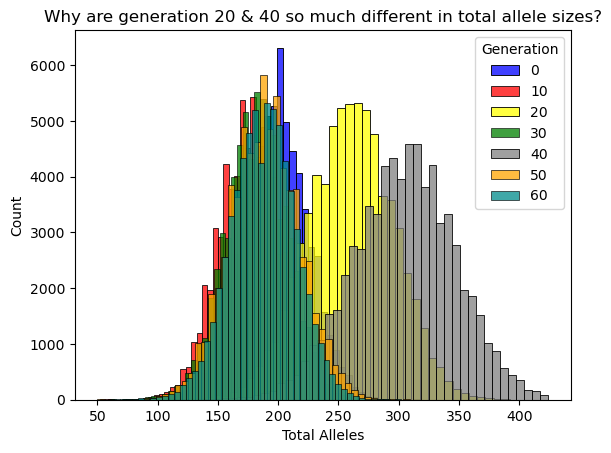

In [147]:
sns.histplot(data=df, x='total_t0', color='blue', label='0', bins=50)
sns.histplot(data=df, x='total_t10', color='red', label='10', bins=50)
sns.histplot(data=df, x='total_t20', color='yellow', label='20', bins=50)
sns.histplot(data=df, x='total_t30', color='green', label='30', bins=50)
sns.histplot(data=df, x='total_t40', color='grey', label='40', bins=50)
sns.histplot(data=df, x='total_t50', color='orange', label='50', bins=50)
sns.histplot(data=df, x='total_t60', color='darkcyan', label='60', bins=50)

plt.title("Why are generation 20 & 40 so much different in total allele sizes?")
plt.xlabel("Total Alleles")
plt.legend(title="Generation")
plt.show()

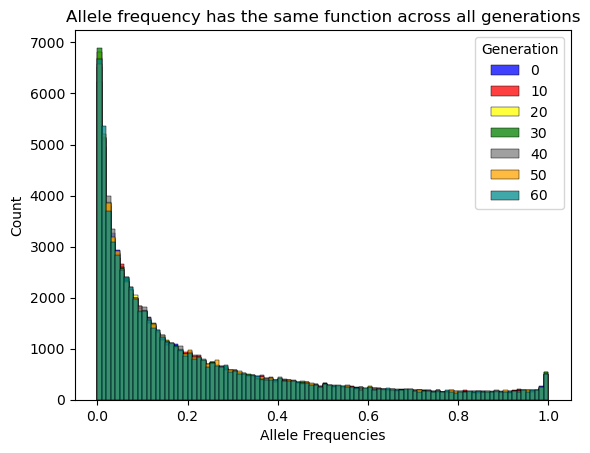

In [148]:
sns.histplot(data=df, x='freq_t0', color='blue', label='0', bins=100)
sns.histplot(data=df, x='freq_t10', color='red', label='10', bins=100)
sns.histplot(data=df, x='freq_t20', color='yellow', label='20', bins=100)
sns.histplot(data=df, x='freq_t30', color='green', label='30', bins=100)
sns.histplot(data=df, x='freq_t40', color='grey', label='40', bins=100)
sns.histplot(data=df, x='freq_t50', color='orange', label='50', bins=100)
sns.histplot(data=df, x='freq_t60', color='darkcyan', label='60', bins=100)

plt.title("Allele frequency has the same function across all generations")
plt.xlabel("Allele Frequencies")
plt.legend(title="Generation")
plt.show()

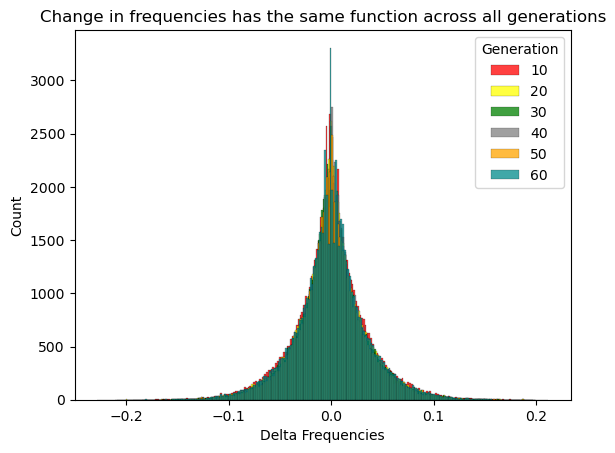

In [149]:
sns.histplot(data=df, x='delta_t10', color='red', label='10')
sns.histplot(data=df, x='delta_t20', color='yellow', label='20')
sns.histplot(data=df, x='delta_t30', color='green', label='30')
sns.histplot(data=df, x='delta_t40', color='grey', label='40')
sns.histplot(data=df, x='delta_t50', color='orange', label='50')
sns.histplot(data=df, x='delta_t60', color='darkcyan', label='60')

plt.title("Change in frequencies has the same function across all generations")
plt.xlabel("Delta Frequencies")
plt.legend(title="Generation")
plt.show()

In [9]:
sim_df = pd.DataFrame()
sim_df['position'] = pd.read_csv("../slim/inputs/admixture_mapping_targets.csv", header=None)

for generation in range(1, 7):
    sim_i = pd.read_csv(f"../slim/outputs/65755-70000-0-_Cycle_{generation}0.txt")
    sim_df[f"sim_t{generation}0"] = sim_i[f"Frequency_{generation}0"]

sim_df

,position,sim_t10,sim_t20,sim_t30,sim_t40,sim_t50,sim_t60
0,1000020,0,0,0,0,0,0
1,1000025,0,0,0,0,0,0
2,1000034,0,0,0,0,0,0
3,1000045,0,0,0,0,0,0
4,1000063,0,0,0,0,0,0
...,...,...,...,...,...,...,...
69995,2458912,0,0,0,0,0,0
69996,2458931,0,0,0,0,0,0
69997,2458939,0,0,0,0,0,0
69998,2458947,0,0,0,0,0,0


In [ ]:
final = df.merge(sim_df, on='position', how='inner')
final

In [ ]:
sim_df[sim_df.sim_t60 != 0]

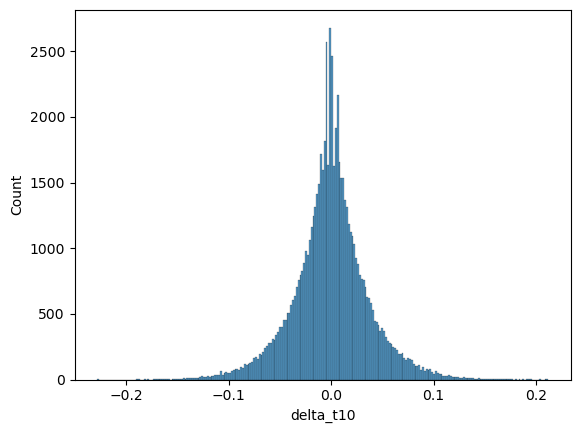

In [ ]:
sns.histplot(data=df, x='delta_t10')
plt.show()

sns.histplot(data=df, x='delta_t10', y='delta_t20', hue='delta_t30')
plt.title
plt.show()

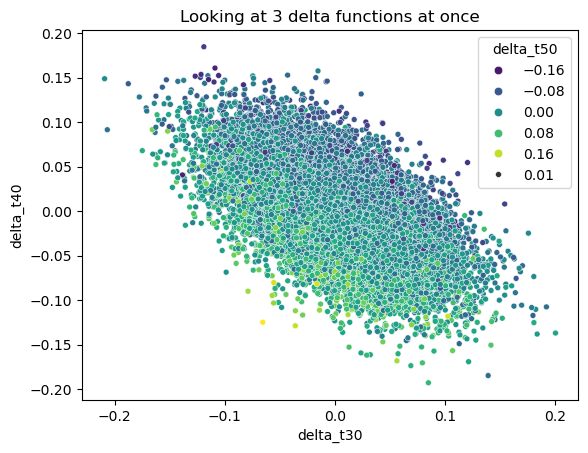

In [150]:
sns.scatterplot(data=df, x='delta_t30', y='delta_t40', hue='delta_t50', size=.01, palette='viridis')
plt.title("Looking at 3 delta functions at once")
plt.show()

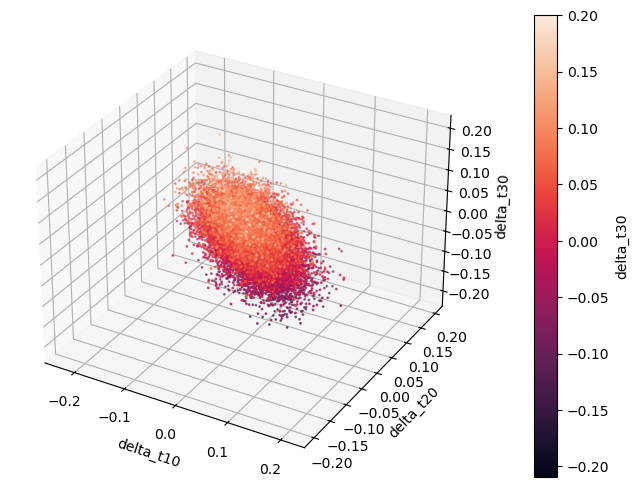

In [30]:

def plot3Dgraphs(col1, col2, col3):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(projection='3d')
    
    # 2. Plot using the 3D axis object
    # We use c=df['delta_t50'] to keep the 'viridis' color mapping (hue)
    img = ax.scatter(
        df[col1], 
        df[col2], 
        df[col3], 
        c=df[col3], 
        cmap='rocket', 
        s=1 # Adjusted size from .01 so points are visible
    )
    
    # 3. Add labels for all three dimensions
    ax.set_xlabel(col1)
    ax.set_ylabel(col2)
    ax.set_zlabel(col3)
    
    # 4. Add a colorbar to act as your 'hue' legend
    fig.colorbar(img, ax=ax, label=col3, pad=0.1)
    plt.show()

plot3Dgraphs("delta_t10", "delta_t20", "delta_t30")

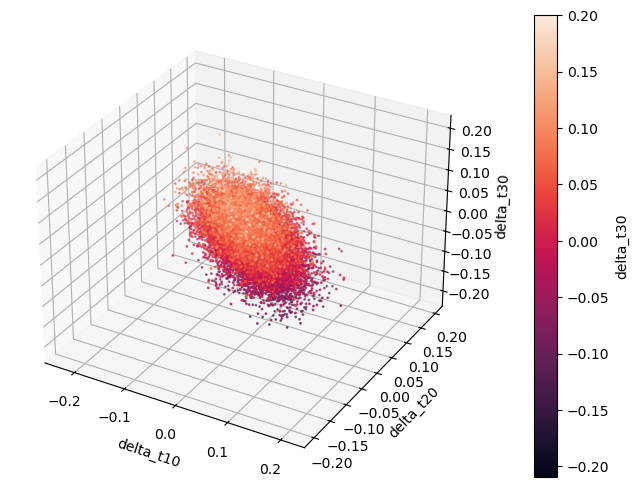

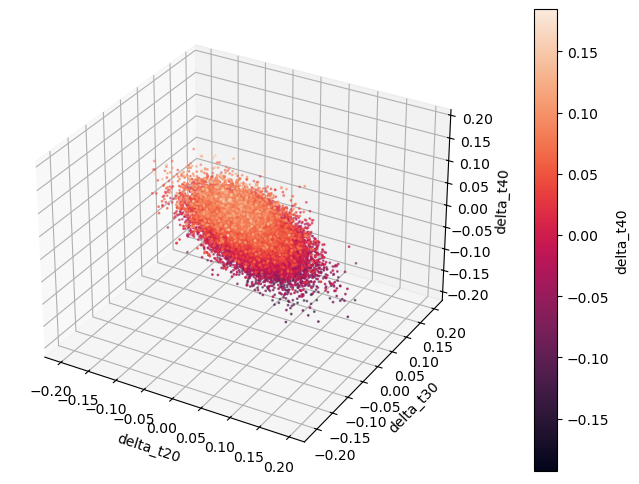

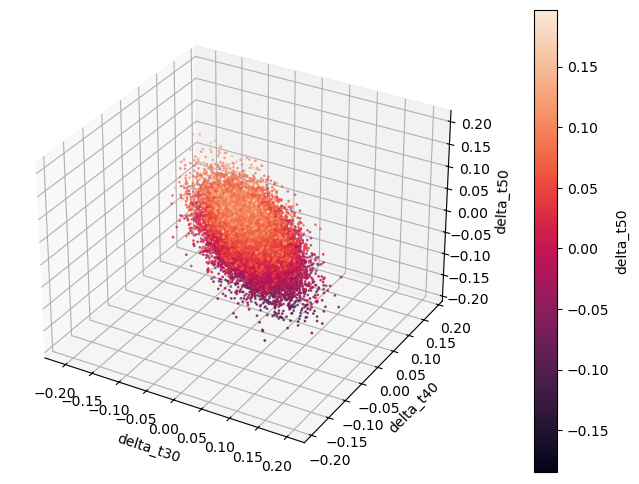

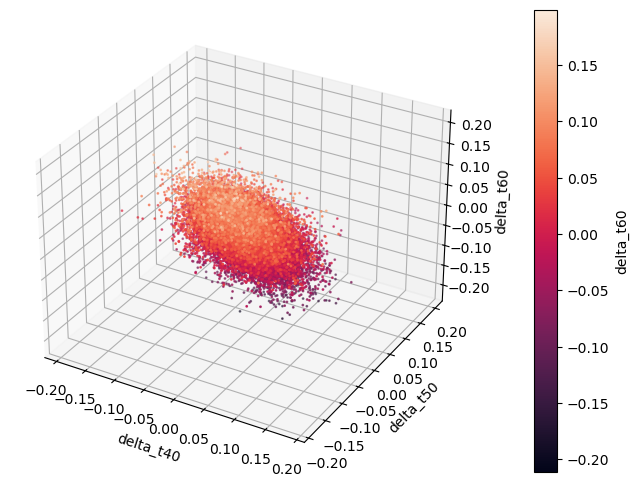

In [31]:
for t in [10, 20, 30, 40]:
    t_1 = t
    t_2 = t + 10
    t_3 = t + 20
    plot3Dgraphs(f'delta_t{t_1}', f'delta_t{t_2}', f'delta_t{t_3}')

In [7]:
df['avg_delta'] = (df['delta_t10'] + df['delta_t20'] + df['delta_t30'] + df['delta_t40'] + df['delta_t50'] + df['delta_t60']) / 6

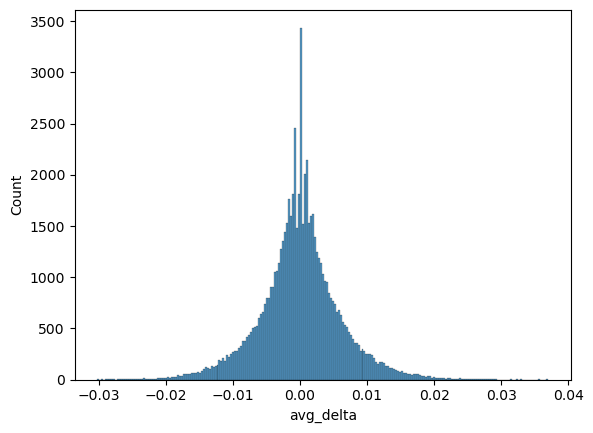

In [8]:
sns.histplot(data=df, x='avg_delta')
plt.show()

In [11]:
import numpy as np
import scipy

<Axes: xlabel='phi_est', ylabel='Count'>

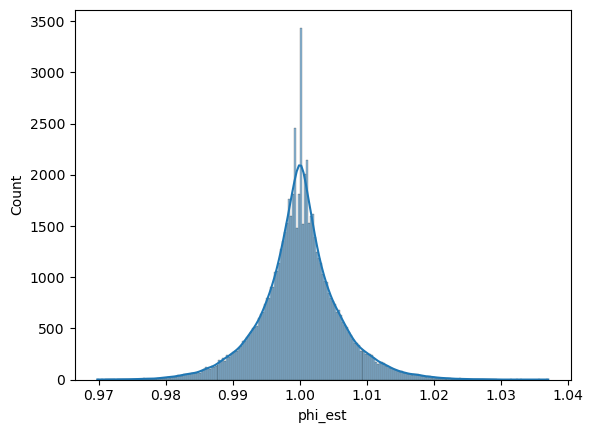

In [22]:
df['phi_est'] = df['avg_delta'] + 1
sns.histplot(data=df, x='phi_est', kde=True)

In [40]:
import numpy as np
import pandas as pd
import subprocess

def sampleAndSimulate(alpha, beta, seed=42):
    gamma_samples = np.random.default_rng(seed=seed).gamma(shape=alpha, scale=1/alpha, size=70_000)
    s_samples = gamma_samples - 1
    pd.DataFrame(gamma_samples).to_csv('../slim/inputs/gamma_distributed_sample.csv', index=False, header=False)

    # Find fitness coefficients that work
    print("Simulating ...")
    result = subprocess.run(['time', 'slim', '-x', '../slim/simulate_one.slim'], capture_output=True, text=True)
    # print(result.stdout)
    if result.stderr:
        print("STDERR:\n", result.stderr)

    print("Simulation complete - reading files ...")
    sim_df = pd.DataFrame()
    
    sim_df['position'] = pd.read_csv("../slim/inputs/admixture_mapping_targets.csv", header=None)
    for generation in range(1, 7):
        sim_i = pd.read_csv(f"../slim/outputs/65755-70000-0-_Cycle_{generation}0.txt")
        sim_df[f"sim_{generation}0"] = sim_i[f"Frequency_{generation}0"]

    # Turn mutations into allele frequencies
    for i in [10,20,30,40,50,60]:
        sim[f'sim_{i}'] = sim[f'sim_{i}'] / 2000

    # Deltas
    
    
    return sim_df

sampleAndSimulate(alpha=2, beta=2)

Simulating ...
STDERR:
 // ********** The -x command-line option has disabled some runtime checks

146.60user 0.06system 2:26.90elapsed 99%CPU (0avgtext+0avgdata 161076maxresident)k
0inputs+2648outputs (0major+40396minor)pagefaults 0swaps

Simulation complete - reading files ...


,position,sim_10,sim_20,sim_30,sim_40,sim_50,sim_60
0,1000020,4,0,0,0,0,0
1,1000025,0,0,0,0,0,0
2,1000034,34,0,0,0,0,0
3,1000045,0,0,0,0,0,0
4,1000063,0,0,0,0,0,0
...,...,...,...,...,...,...,...
69995,2458912,0,0,0,0,0,0
69996,2458931,0,0,0,0,0,0
69997,2458939,0,0,0,0,0,0
69998,2458947,0,0,0,0,0,0


In [17]:
sim = sampleAndSimulate(alpha=2, beta=1)
sim[sim.sim_60 != 0]

Simulating ...
// Initial random seed:
9042776500533841016

// RunInitializeCallbacks():
initializeSLiMOptions(keepPedigrees = T);
initializeSex("A");
initializeMutationRate(0);
initializeMutationType(1, 0.5, "f", 0);
initializeMutationType(2, 0.5, "f", 0);
initializeGenomicElementType(1, m2, 1);
initializeGenomicElement(g1, 0, 23513711);
initializeRecombinationRate(c(0, 0, 0, 2.3455e-09, 2.3455e-09, 1.99368e-08, 1.4073e-08, 1.05548e-08, 2.3455e-08, 3.04915e-08, 3.40098e-08, 2.8146e-08, 3.63553e-08, 1.75913e-08, 7.0365e-09, 2.46278e-08, 2.93188e-08, 2.22823e-08, 1.75913e-08, 5.39465e-08, 2.46278e-08, 1.64185e-08, 3.63553e-08, 1.64185e-08, 4.691e-08, 2.58005e-08, 2.58005e-08, 5.74648e-08, 2.22823e-08, 9.38201e-09, 1.05548e-08, 6.91923e-08, 2.3455e-08, 2.3455e-08, 5.04283e-08, 4.2219e-08, 1.8764e-08, 3.63553e-08, 7.5056e-08, 7.38833e-08, 6.68468e-08, 3.63553e-08, 7.27105e-08, 5.74648e-08, 4.10463e-08, 1.8764e-08, 1.75913e-08, 5.1601e-08, 9.49928e-08, 6.33285e-08, ...), c(99999, 199999, 2

,position,sim_10,sim_20,sim_30,sim_40,sim_50,sim_60
263,1003463,84,1012,1490,1997,2000,2000
275,1003840,85,1012,1490,1997,2000,2000
433,1007438,74,1014,1490,1997,2000,2000
465,1007780,61,1014,1490,1997,2000,2000
478,1007843,81,1014,1490,1997,2000,2000
...,...,...,...,...,...,...,...
9695,1183315,130,1025,1003,1871,2000,2000
9814,1185421,37,1025,1003,1871,2000,2000
9827,1185479,37,1025,1003,1871,2000,2000
9899,1187011,79,975,1025,1444,2000,2000


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

def compareResults(real, sim):
    sns.histplot(data=real, x='freq_t60')
    plt.show()

    sns.histplot(data=sim, x='')

np.int64(200)

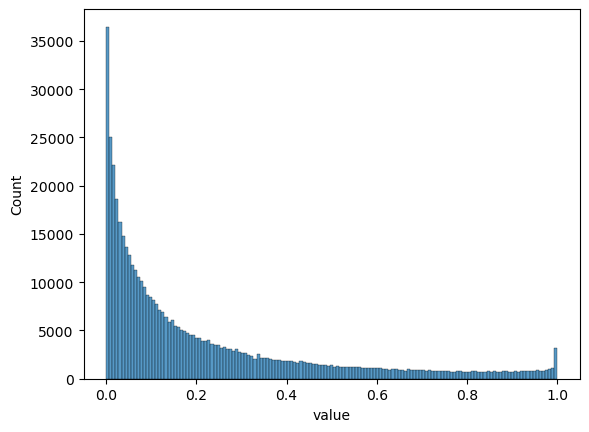

Simulating ...
// Initial random seed:
8018032272797513387

// RunInitializeCallbacks():
initializeSLiMOptions(keepPedigrees = T);
initializeSex("A");
initializeMutationRate(0);
initializeMutationType(1, 0.5, "f", 0);
initializeMutationType(2, 0.5, "f", 0);
initializeGenomicElementType(1, m2, 1);
initializeGenomicElement(g1, 0, 23513711);
initializeRecombinationRate(c(0, 0, 0, 2.3455e-09, 2.3455e-09, 1.99368e-08, 1.4073e-08, 1.05548e-08, 2.3455e-08, 3.04915e-08, 3.40098e-08, 2.8146e-08, 3.63553e-08, 1.75913e-08, 7.0365e-09, 2.46278e-08, 2.93188e-08, 2.22823e-08, 1.75913e-08, 5.39465e-08, 2.46278e-08, 1.64185e-08, 3.63553e-08, 1.64185e-08, 4.691e-08, 2.58005e-08, 2.58005e-08, 5.74648e-08, 2.22823e-08, 9.38201e-09, 1.05548e-08, 6.91923e-08, 2.3455e-08, 2.3455e-08, 5.04283e-08, 4.2219e-08, 1.8764e-08, 3.63553e-08, 7.5056e-08, 7.38833e-08, 6.68468e-08, 3.63553e-08, 7.27105e-08, 5.74648e-08, 4.10463e-08, 1.8764e-08, 1.75913e-08, 5.1601e-08, 9.49928e-08, 6.33285e-08, ...), c(99999, 199999, 2

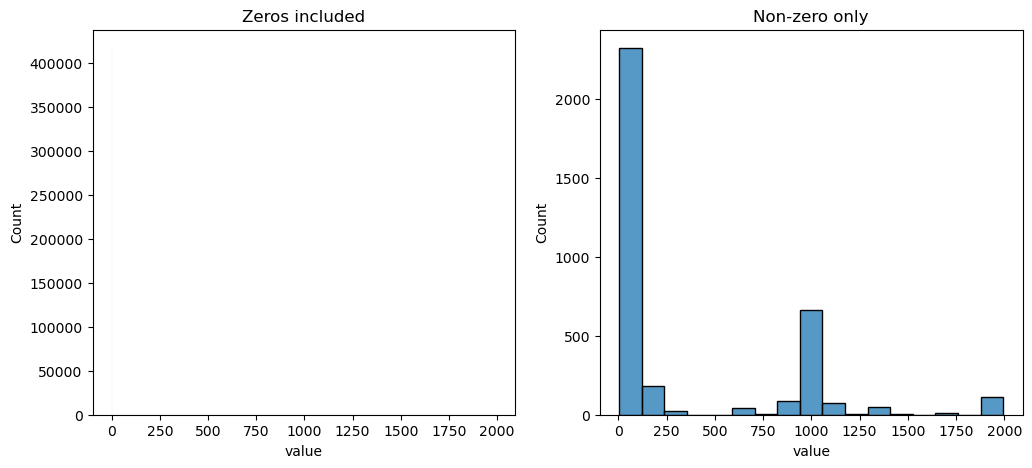

Simulating ...
// Initial random seed:
5961785996438124636

// RunInitializeCallbacks():
initializeSLiMOptions(keepPedigrees = T);
initializeSex("A");
initializeMutationRate(0);
initializeMutationType(1, 0.5, "f", 0);
initializeMutationType(2, 0.5, "f", 0);
initializeGenomicElementType(1, m2, 1);
initializeGenomicElement(g1, 0, 23513711);
initializeRecombinationRate(c(0, 0, 0, 2.3455e-09, 2.3455e-09, 1.99368e-08, 1.4073e-08, 1.05548e-08, 2.3455e-08, 3.04915e-08, 3.40098e-08, 2.8146e-08, 3.63553e-08, 1.75913e-08, 7.0365e-09, 2.46278e-08, 2.93188e-08, 2.22823e-08, 1.75913e-08, 5.39465e-08, 2.46278e-08, 1.64185e-08, 3.63553e-08, 1.64185e-08, 4.691e-08, 2.58005e-08, 2.58005e-08, 5.74648e-08, 2.22823e-08, 9.38201e-09, 1.05548e-08, 6.91923e-08, 2.3455e-08, 2.3455e-08, 5.04283e-08, 4.2219e-08, 1.8764e-08, 3.63553e-08, 7.5056e-08, 7.38833e-08, 6.68468e-08, 3.63553e-08, 7.27105e-08, 5.74648e-08, 4.10463e-08, 1.8764e-08, 1.75913e-08, 5.1601e-08, 9.49928e-08, 6.33285e-08, ...), c(99999, 199999, 2

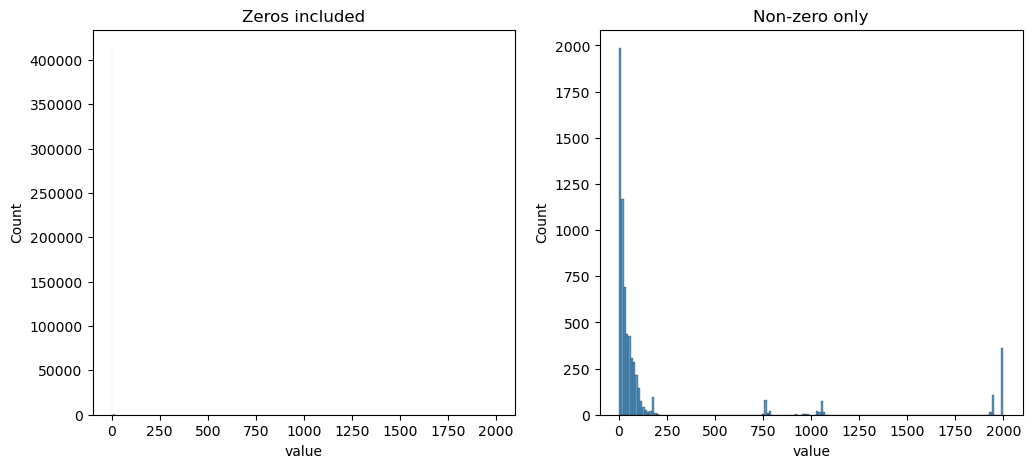

Simulating ...
// Initial random seed:
227788408309696281

// RunInitializeCallbacks():
initializeSLiMOptions(keepPedigrees = T);
initializeSex("A");
initializeMutationRate(0);
initializeMutationType(1, 0.5, "f", 0);
initializeMutationType(2, 0.5, "f", 0);
initializeGenomicElementType(1, m2, 1);
initializeGenomicElement(g1, 0, 23513711);
initializeRecombinationRate(c(0, 0, 0, 2.3455e-09, 2.3455e-09, 1.99368e-08, 1.4073e-08, 1.05548e-08, 2.3455e-08, 3.04915e-08, 3.40098e-08, 2.8146e-08, 3.63553e-08, 1.75913e-08, 7.0365e-09, 2.46278e-08, 2.93188e-08, 2.22823e-08, 1.75913e-08, 5.39465e-08, 2.46278e-08, 1.64185e-08, 3.63553e-08, 1.64185e-08, 4.691e-08, 2.58005e-08, 2.58005e-08, 5.74648e-08, 2.22823e-08, 9.38201e-09, 1.05548e-08, 6.91923e-08, 2.3455e-08, 2.3455e-08, 5.04283e-08, 4.2219e-08, 1.8764e-08, 3.63553e-08, 7.5056e-08, 7.38833e-08, 6.68468e-08, 3.63553e-08, 7.27105e-08, 5.74648e-08, 4.10463e-08, 1.8764e-08, 1.75913e-08, 5.1601e-08, 9.49928e-08, 6.33285e-08, ...), c(99999, 199999, 29

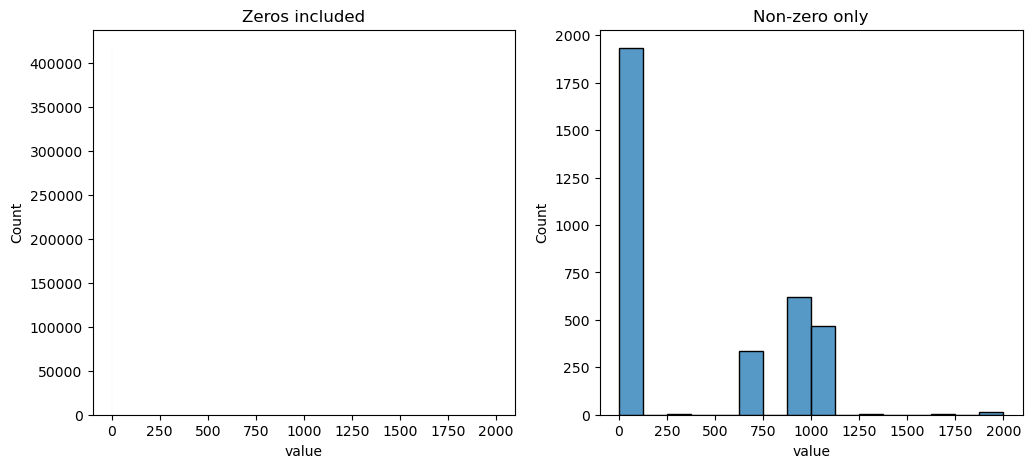

Simulating ...
// Initial random seed:
3327241617963062996

// RunInitializeCallbacks():
initializeSLiMOptions(keepPedigrees = T);
initializeSex("A");
initializeMutationRate(0);
initializeMutationType(1, 0.5, "f", 0);
initializeMutationType(2, 0.5, "f", 0);
initializeGenomicElementType(1, m2, 1);
initializeGenomicElement(g1, 0, 23513711);
initializeRecombinationRate(c(0, 0, 0, 2.3455e-09, 2.3455e-09, 1.99368e-08, 1.4073e-08, 1.05548e-08, 2.3455e-08, 3.04915e-08, 3.40098e-08, 2.8146e-08, 3.63553e-08, 1.75913e-08, 7.0365e-09, 2.46278e-08, 2.93188e-08, 2.22823e-08, 1.75913e-08, 5.39465e-08, 2.46278e-08, 1.64185e-08, 3.63553e-08, 1.64185e-08, 4.691e-08, 2.58005e-08, 2.58005e-08, 5.74648e-08, 2.22823e-08, 9.38201e-09, 1.05548e-08, 6.91923e-08, 2.3455e-08, 2.3455e-08, 5.04283e-08, 4.2219e-08, 1.8764e-08, 3.63553e-08, 7.5056e-08, 7.38833e-08, 6.68468e-08, 3.63553e-08, 7.27105e-08, 5.74648e-08, 4.10463e-08, 1.8764e-08, 1.75913e-08, 5.1601e-08, 9.49928e-08, 6.33285e-08, ...), c(99999, 199999, 2

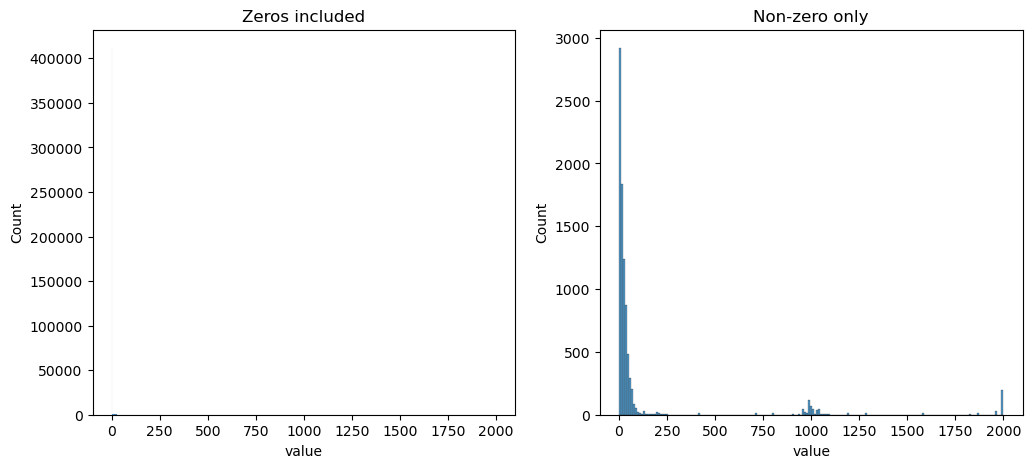

Simulating ...
// Initial random seed:
8022568562653245552

// RunInitializeCallbacks():
initializeSLiMOptions(keepPedigrees = T);
initializeSex("A");
initializeMutationRate(0);
initializeMutationType(1, 0.5, "f", 0);
initializeMutationType(2, 0.5, "f", 0);
initializeGenomicElementType(1, m2, 1);
initializeGenomicElement(g1, 0, 23513711);
initializeRecombinationRate(c(0, 0, 0, 2.3455e-09, 2.3455e-09, 1.99368e-08, 1.4073e-08, 1.05548e-08, 2.3455e-08, 3.04915e-08, 3.40098e-08, 2.8146e-08, 3.63553e-08, 1.75913e-08, 7.0365e-09, 2.46278e-08, 2.93188e-08, 2.22823e-08, 1.75913e-08, 5.39465e-08, 2.46278e-08, 1.64185e-08, 3.63553e-08, 1.64185e-08, 4.691e-08, 2.58005e-08, 2.58005e-08, 5.74648e-08, 2.22823e-08, 9.38201e-09, 1.05548e-08, 6.91923e-08, 2.3455e-08, 2.3455e-08, 5.04283e-08, 4.2219e-08, 1.8764e-08, 3.63553e-08, 7.5056e-08, 7.38833e-08, 6.68468e-08, 3.63553e-08, 7.27105e-08, 5.74648e-08, 4.10463e-08, 1.8764e-08, 1.75913e-08, 5.1601e-08, 9.49928e-08, 6.33285e-08, ...), c(99999, 199999, 2

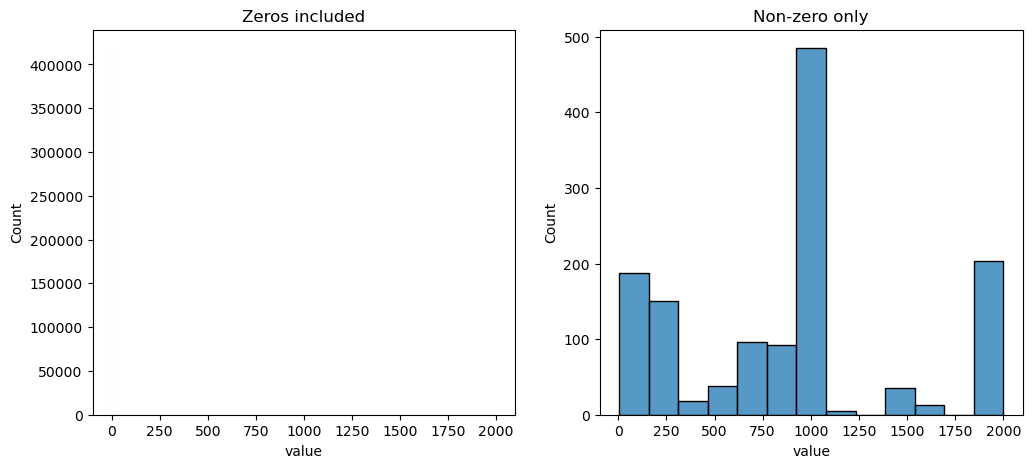

Simulating ...
// Initial random seed:
7887586175515800542

// RunInitializeCallbacks():
initializeSLiMOptions(keepPedigrees = T);
initializeSex("A");
initializeMutationRate(0);
initializeMutationType(1, 0.5, "f", 0);
initializeMutationType(2, 0.5, "f", 0);
initializeGenomicElementType(1, m2, 1);
initializeGenomicElement(g1, 0, 23513711);
initializeRecombinationRate(c(0, 0, 0, 2.3455e-09, 2.3455e-09, 1.99368e-08, 1.4073e-08, 1.05548e-08, 2.3455e-08, 3.04915e-08, 3.40098e-08, 2.8146e-08, 3.63553e-08, 1.75913e-08, 7.0365e-09, 2.46278e-08, 2.93188e-08, 2.22823e-08, 1.75913e-08, 5.39465e-08, 2.46278e-08, 1.64185e-08, 3.63553e-08, 1.64185e-08, 4.691e-08, 2.58005e-08, 2.58005e-08, 5.74648e-08, 2.22823e-08, 9.38201e-09, 1.05548e-08, 6.91923e-08, 2.3455e-08, 2.3455e-08, 5.04283e-08, 4.2219e-08, 1.8764e-08, 3.63553e-08, 7.5056e-08, 7.38833e-08, 6.68468e-08, 3.63553e-08, 7.27105e-08, 5.74648e-08, 4.10463e-08, 1.8764e-08, 1.75913e-08, 5.1601e-08, 9.49928e-08, 6.33285e-08, ...), c(99999, 199999, 2

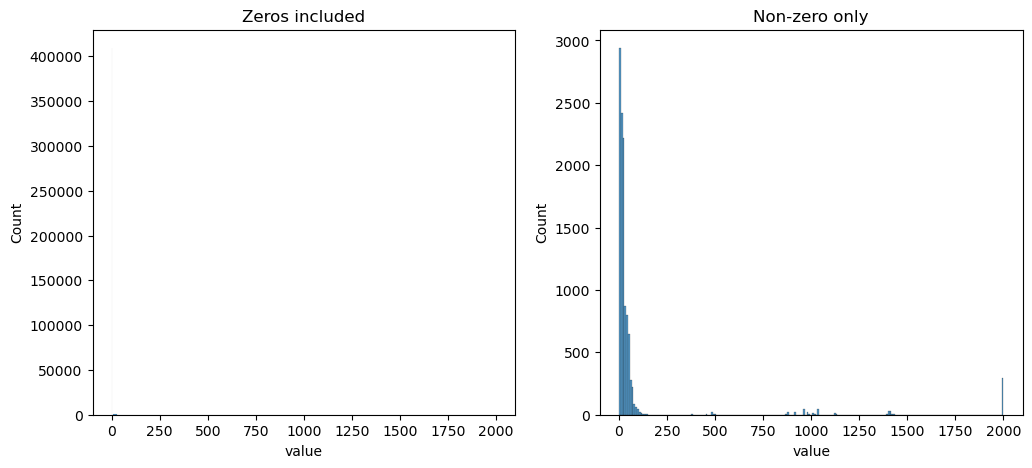

Simulating ...
// Initial random seed:
8242305522843478142

// RunInitializeCallbacks():
initializeSLiMOptions(keepPedigrees = T);
initializeSex("A");
initializeMutationRate(0);
initializeMutationType(1, 0.5, "f", 0);
initializeMutationType(2, 0.5, "f", 0);
initializeGenomicElementType(1, m2, 1);
initializeGenomicElement(g1, 0, 23513711);
initializeRecombinationRate(c(0, 0, 0, 2.3455e-09, 2.3455e-09, 1.99368e-08, 1.4073e-08, 1.05548e-08, 2.3455e-08, 3.04915e-08, 3.40098e-08, 2.8146e-08, 3.63553e-08, 1.75913e-08, 7.0365e-09, 2.46278e-08, 2.93188e-08, 2.22823e-08, 1.75913e-08, 5.39465e-08, 2.46278e-08, 1.64185e-08, 3.63553e-08, 1.64185e-08, 4.691e-08, 2.58005e-08, 2.58005e-08, 5.74648e-08, 2.22823e-08, 9.38201e-09, 1.05548e-08, 6.91923e-08, 2.3455e-08, 2.3455e-08, 5.04283e-08, 4.2219e-08, 1.8764e-08, 3.63553e-08, 7.5056e-08, 7.38833e-08, 6.68468e-08, 3.63553e-08, 7.27105e-08, 5.74648e-08, 4.10463e-08, 1.8764e-08, 1.75913e-08, 5.1601e-08, 9.49928e-08, 6.33285e-08, ...), c(99999, 199999, 2

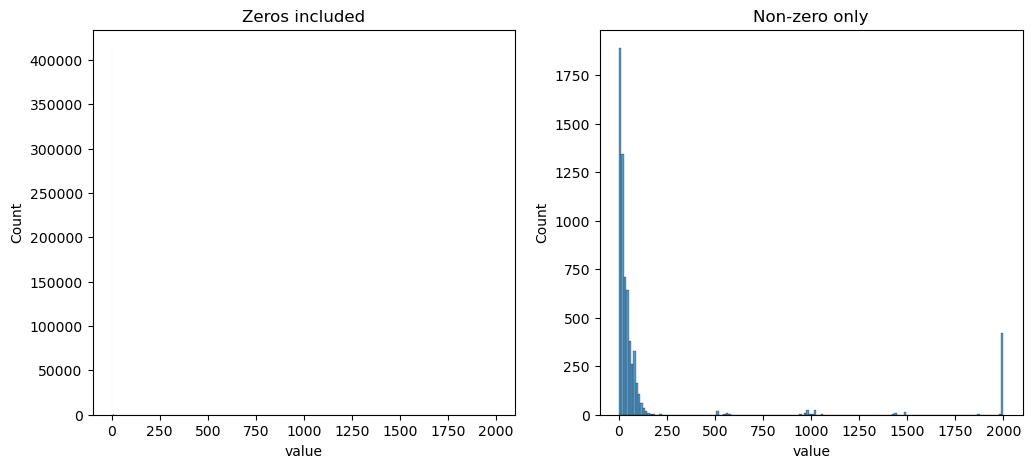

Simulating ...
// Initial random seed:
4730987396851345063

// RunInitializeCallbacks():
initializeSLiMOptions(keepPedigrees = T);
initializeSex("A");
initializeMutationRate(0);
initializeMutationType(1, 0.5, "f", 0);
initializeMutationType(2, 0.5, "f", 0);
initializeGenomicElementType(1, m2, 1);
initializeGenomicElement(g1, 0, 23513711);
initializeRecombinationRate(c(0, 0, 0, 2.3455e-09, 2.3455e-09, 1.99368e-08, 1.4073e-08, 1.05548e-08, 2.3455e-08, 3.04915e-08, 3.40098e-08, 2.8146e-08, 3.63553e-08, 1.75913e-08, 7.0365e-09, 2.46278e-08, 2.93188e-08, 2.22823e-08, 1.75913e-08, 5.39465e-08, 2.46278e-08, 1.64185e-08, 3.63553e-08, 1.64185e-08, 4.691e-08, 2.58005e-08, 2.58005e-08, 5.74648e-08, 2.22823e-08, 9.38201e-09, 1.05548e-08, 6.91923e-08, 2.3455e-08, 2.3455e-08, 5.04283e-08, 4.2219e-08, 1.8764e-08, 3.63553e-08, 7.5056e-08, 7.38833e-08, 6.68468e-08, 3.63553e-08, 7.27105e-08, 5.74648e-08, 4.10463e-08, 1.8764e-08, 1.75913e-08, 5.1601e-08, 9.49928e-08, 6.33285e-08, ...), c(99999, 199999, 2

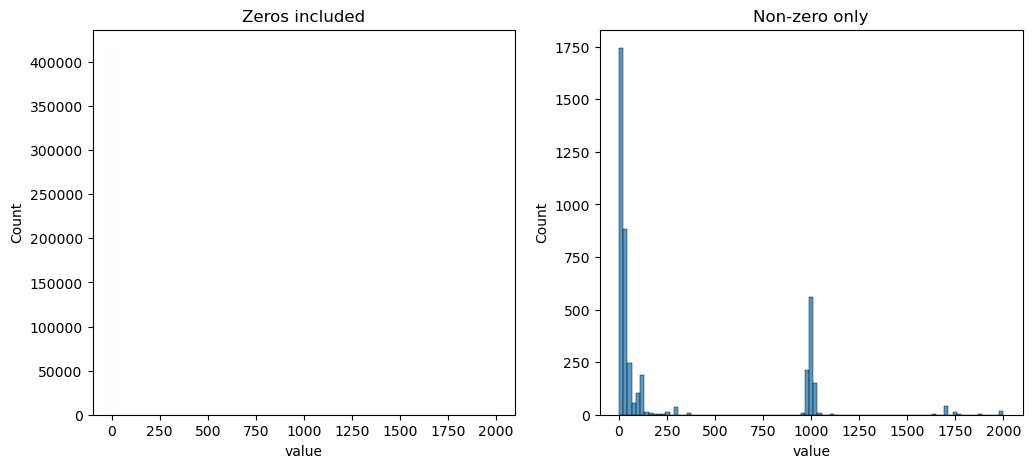

Simulating ...
// Initial random seed:
3218518517675839367

// RunInitializeCallbacks():
initializeSLiMOptions(keepPedigrees = T);
initializeSex("A");
initializeMutationRate(0);
initializeMutationType(1, 0.5, "f", 0);
initializeMutationType(2, 0.5, "f", 0);
initializeGenomicElementType(1, m2, 1);
initializeGenomicElement(g1, 0, 23513711);
initializeRecombinationRate(c(0, 0, 0, 2.3455e-09, 2.3455e-09, 1.99368e-08, 1.4073e-08, 1.05548e-08, 2.3455e-08, 3.04915e-08, 3.40098e-08, 2.8146e-08, 3.63553e-08, 1.75913e-08, 7.0365e-09, 2.46278e-08, 2.93188e-08, 2.22823e-08, 1.75913e-08, 5.39465e-08, 2.46278e-08, 1.64185e-08, 3.63553e-08, 1.64185e-08, 4.691e-08, 2.58005e-08, 2.58005e-08, 5.74648e-08, 2.22823e-08, 9.38201e-09, 1.05548e-08, 6.91923e-08, 2.3455e-08, 2.3455e-08, 5.04283e-08, 4.2219e-08, 1.8764e-08, 3.63553e-08, 7.5056e-08, 7.38833e-08, 6.68468e-08, 3.63553e-08, 7.27105e-08, 5.74648e-08, 4.10463e-08, 1.8764e-08, 1.75913e-08, 5.1601e-08, 9.49928e-08, 6.33285e-08, ...), c(99999, 199999, 2

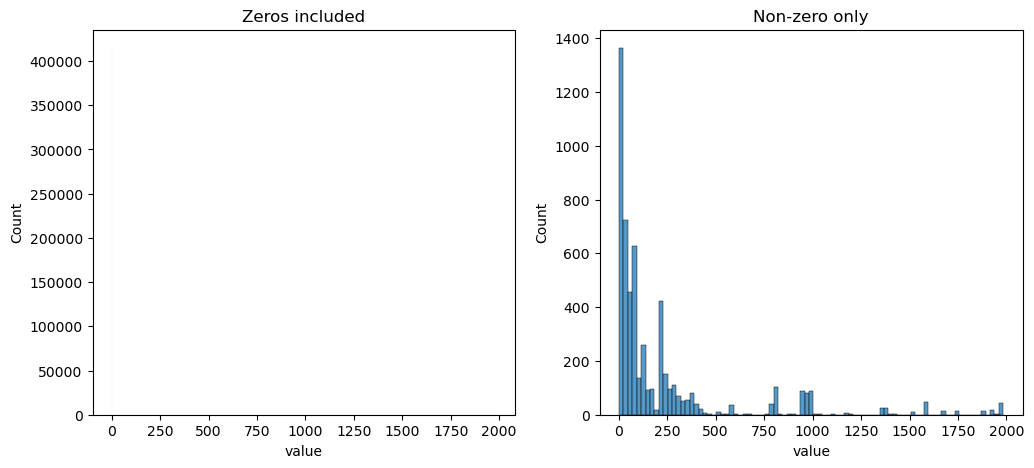

Simulating ...
// Initial random seed:
4275783849222851256

// RunInitializeCallbacks():
initializeSLiMOptions(keepPedigrees = T);
initializeSex("A");
initializeMutationRate(0);
initializeMutationType(1, 0.5, "f", 0);
initializeMutationType(2, 0.5, "f", 0);
initializeGenomicElementType(1, m2, 1);
initializeGenomicElement(g1, 0, 23513711);
initializeRecombinationRate(c(0, 0, 0, 2.3455e-09, 2.3455e-09, 1.99368e-08, 1.4073e-08, 1.05548e-08, 2.3455e-08, 3.04915e-08, 3.40098e-08, 2.8146e-08, 3.63553e-08, 1.75913e-08, 7.0365e-09, 2.46278e-08, 2.93188e-08, 2.22823e-08, 1.75913e-08, 5.39465e-08, 2.46278e-08, 1.64185e-08, 3.63553e-08, 1.64185e-08, 4.691e-08, 2.58005e-08, 2.58005e-08, 5.74648e-08, 2.22823e-08, 9.38201e-09, 1.05548e-08, 6.91923e-08, 2.3455e-08, 2.3455e-08, 5.04283e-08, 4.2219e-08, 1.8764e-08, 3.63553e-08, 7.5056e-08, 7.38833e-08, 6.68468e-08, 3.63553e-08, 7.27105e-08, 5.74648e-08, 4.10463e-08, 1.8764e-08, 1.75913e-08, 5.1601e-08, 9.49928e-08, 6.33285e-08, ...), c(99999, 199999, 2

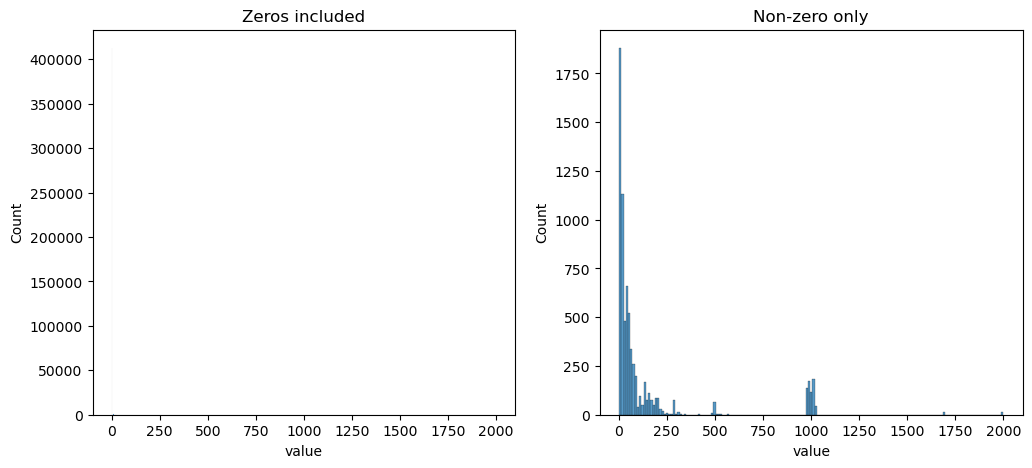

Simulating ...
// Initial random seed:
6253533240247378537

// RunInitializeCallbacks():
initializeSLiMOptions(keepPedigrees = T);
initializeSex("A");
initializeMutationRate(0);
initializeMutationType(1, 0.5, "f", 0);
initializeMutationType(2, 0.5, "f", 0);
initializeGenomicElementType(1, m2, 1);
initializeGenomicElement(g1, 0, 23513711);
initializeRecombinationRate(c(0, 0, 0, 2.3455e-09, 2.3455e-09, 1.99368e-08, 1.4073e-08, 1.05548e-08, 2.3455e-08, 3.04915e-08, 3.40098e-08, 2.8146e-08, 3.63553e-08, 1.75913e-08, 7.0365e-09, 2.46278e-08, 2.93188e-08, 2.22823e-08, 1.75913e-08, 5.39465e-08, 2.46278e-08, 1.64185e-08, 3.63553e-08, 1.64185e-08, 4.691e-08, 2.58005e-08, 2.58005e-08, 5.74648e-08, 2.22823e-08, 9.38201e-09, 1.05548e-08, 6.91923e-08, 2.3455e-08, 2.3455e-08, 5.04283e-08, 4.2219e-08, 1.8764e-08, 3.63553e-08, 7.5056e-08, 7.38833e-08, 6.68468e-08, 3.63553e-08, 7.27105e-08, 5.74648e-08, 4.10463e-08, 1.8764e-08, 1.75913e-08, 5.1601e-08, 9.49928e-08, 6.33285e-08, ...), c(99999, 199999, 2

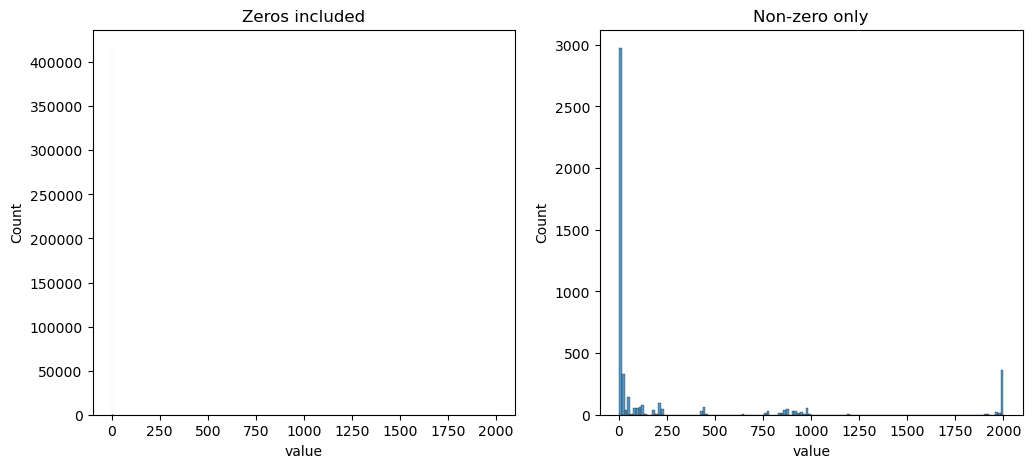

In [39]:
from concurrent.futures import ProcessPoolExecutor

# plot the real frequencies
dflong = df[['position', 'freq_t0', 'freq_t10', 'freq_t20', 'freq_t30', 'freq_t40', 'freq_t50', 'freq_t60']].melt(id_vars=['position'])
sns.histplot(data=dflong, x='value')
plt.show()

for alpha in [0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3]:
    # Sample from gamma and SLiM-ulate
    sim = sampleAndSimulate(alpha=alpha, beta=1/alpha)

    # Plot the full histogram, and the histogram with only non-zero at t=60
    simlong = sim.melt(id_vars=['position'])
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Full simulation
    sns.histplot(data = simlong, x='value', ax=ax[0])
    ax[0].set_title(f"Zeros included (alpha={alpha})")

    # Simulation with only non-zero points at t=60
    sns.histplot(data = simlong[simlong.value != 0], x='value', ax=ax[1])
    ax[1].set_title(f"Non-zero only (alpha={alpha})")
    
    plt.show()

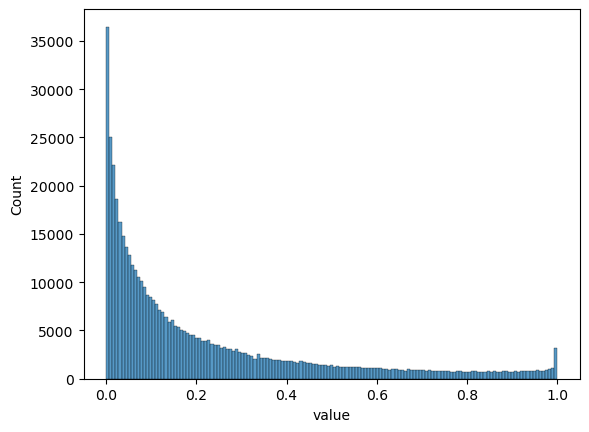

Simulating ...
STDERR:
 // ********** The -x command-line option has disabled some runtime checks

154.77user 0.06system 2:35.22elapsed 99%CPU (0avgtext+0avgdata 160872maxresident)k
0inputs+2640outputs (0major+40340minor)pagefaults 0swaps

Simulation complete - reading files ...


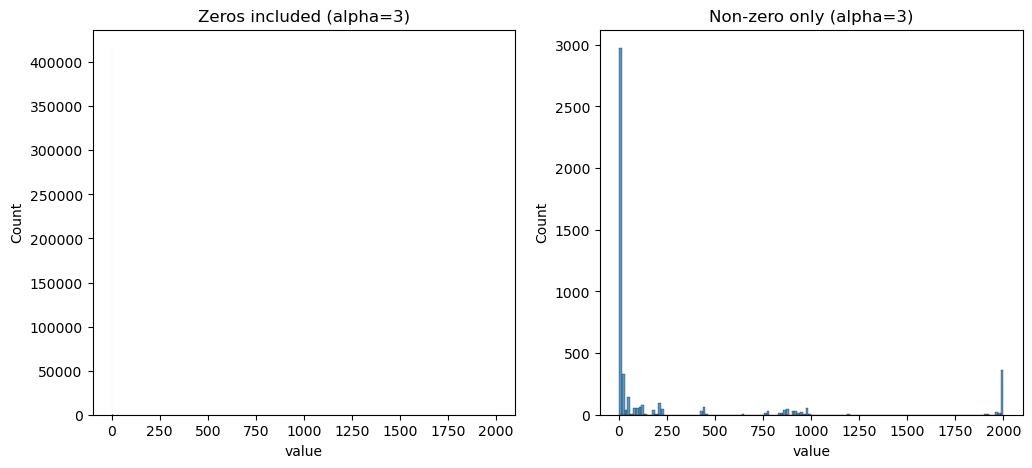

Simulating ...
STDERR:
 // ********** The -x command-line option has disabled some runtime checks

145.30user 0.07system 2:25.64elapsed 99%CPU (0avgtext+0avgdata 161800maxresident)k
0inputs+2640outputs (0major+40623minor)pagefaults 0swaps

Simulation complete - reading files ...


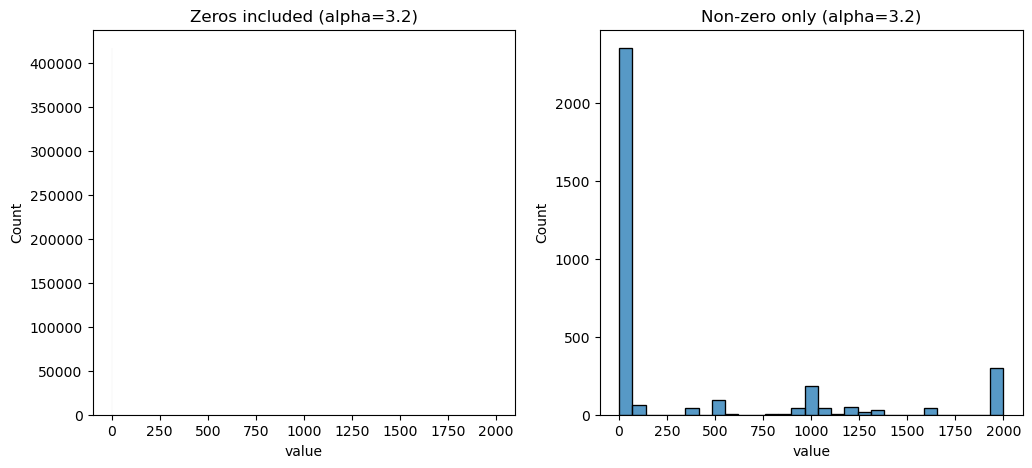

Simulating ...
STDERR:
 // ********** The -x command-line option has disabled some runtime checks

151.45user 0.06system 2:31.76elapsed 99%CPU (0avgtext+0avgdata 162336maxresident)k
0inputs+2640outputs (0major+40694minor)pagefaults 0swaps

Simulation complete - reading files ...


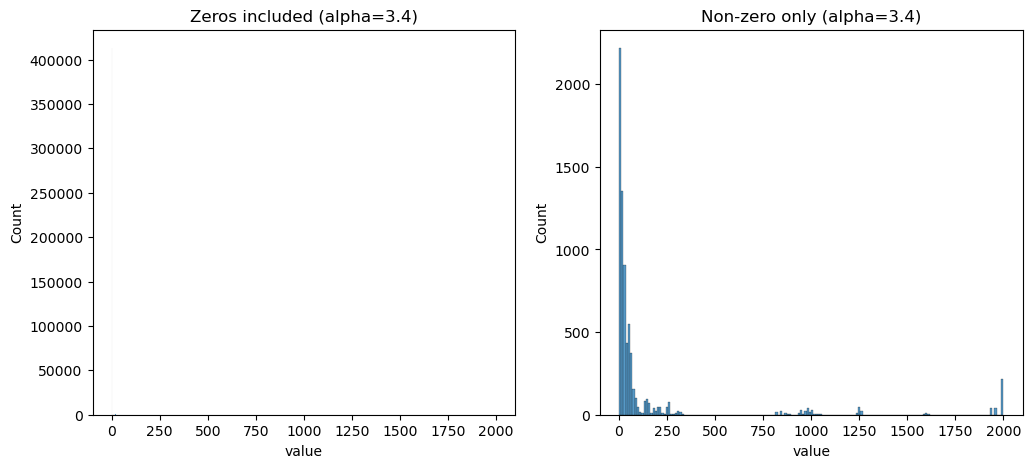

Simulating ...
STDERR:
 // ********** The -x command-line option has disabled some runtime checks

157.18user 0.06system 2:37.53elapsed 99%CPU (0avgtext+0avgdata 161188maxresident)k
0inputs+2640outputs (0major+40407minor)pagefaults 0swaps

Simulation complete - reading files ...


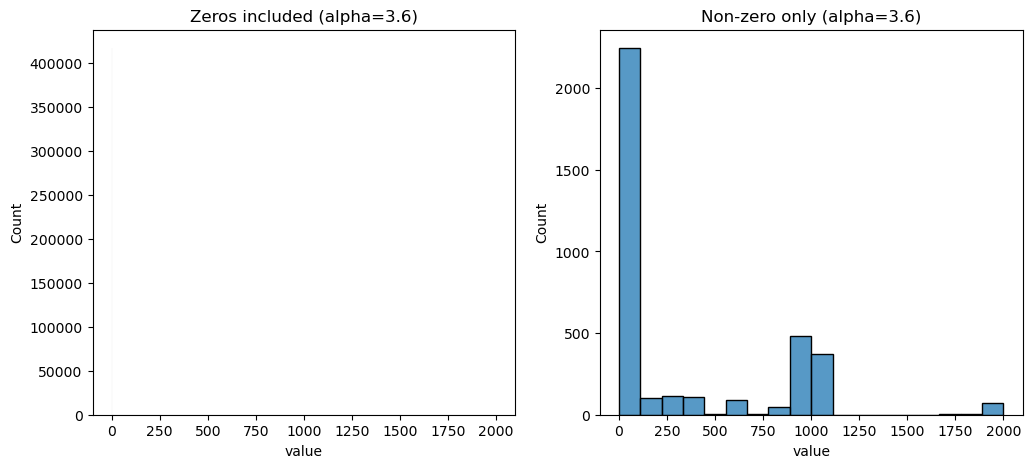

Simulating ...
STDERR:
 // ********** The -x command-line option has disabled some runtime checks

149.74user 0.05system 2:30.06elapsed 99%CPU (0avgtext+0avgdata 160764maxresident)k
0inputs+2648outputs (0major+40303minor)pagefaults 0swaps

Simulation complete - reading files ...


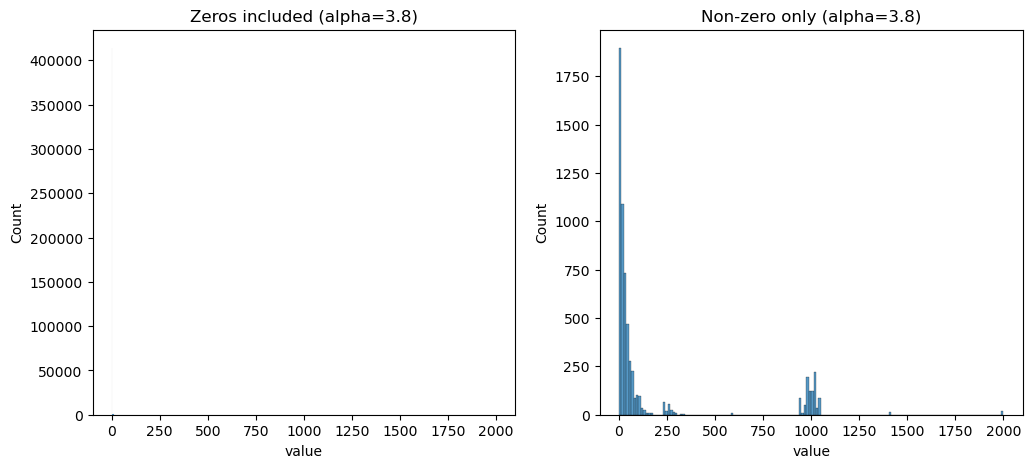

Simulating ...
STDERR:
 // ********** The -x command-line option has disabled some runtime checks

165.35user 0.06system 2:45.71elapsed 99%CPU (0avgtext+0avgdata 162204maxresident)k
0inputs+2640outputs (0major+40741minor)pagefaults 0swaps

Simulation complete - reading files ...


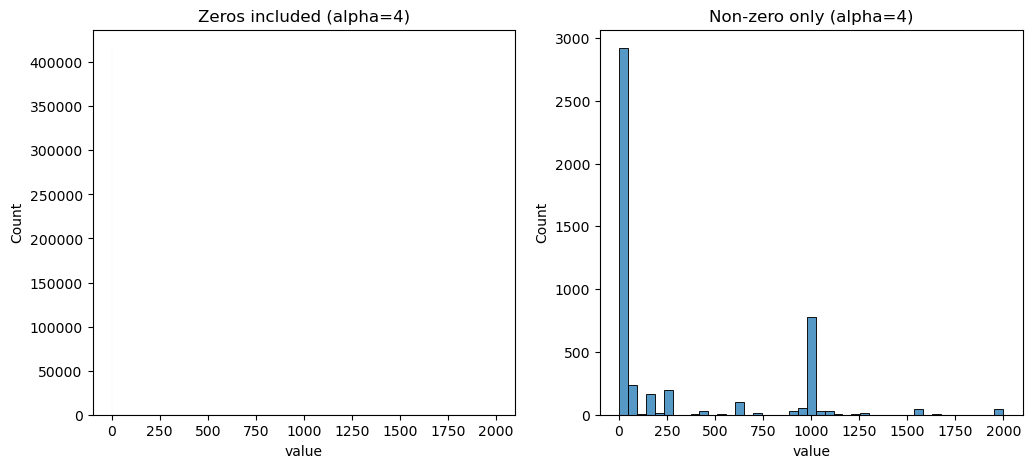

In [42]:
from concurrent.futures import ProcessPoolExecutor

# plot the real frequencies
dflong = df[['position', 'freq_t0', 'freq_t10', 'freq_t20', 'freq_t30', 'freq_t40', 'freq_t50', 'freq_t60']].melt(id_vars=['position'])
sns.histplot(data=dflong, x='value')
plt.show()

for alpha in [3, 3.2, 3.4, 3.6, 3.8, 4]:
    # Sample from gamma and SLiM-ulate
    sim = sampleAndSimulate(alpha=alpha, beta=1/alpha)

    # Plot the full histogram, and the histogram with only non-zero at t=60
    simlong = sim.melt(id_vars=['position'])
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Full simulation
    sns.histplot(data = simlong, x='value', ax=ax[0])
    ax[0].set_title(f"Zeros included (alpha={alpha})")

    # Simulation with only non-zero points at t=60
    sns.histplot(data = simlong[simlong.value != 0], x='value', ax=ax[1])
    ax[1].set_title(f"Non-zero only (alpha={alpha})")
    
    plt.show()

<Axes: ylabel='Count'>

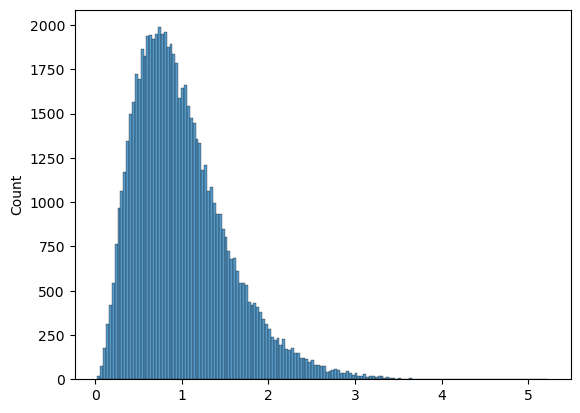

In [67]:
import scipy
gamma = np.random.default_rng(seed=42).gamma(shape=3.4, scale = 1/3.4, size=70_000)
sns.histplot(x=gamma)

In [86]:
df['avg_delta'] = (df['delta_t10'] + df['delta_t20'] + df['delta_t30'] + df['delta_t40'] + df['delta_t50'] + df['delta_t60']) / 6
df['avg_freq'] = (df['freq_t0'] + df['freq_t10'] + df['freq_t20'] + df['freq_t30'] + df['freq_t40'] + df['freq_t50'] + df['freq_t60']) / 7
df['s_est'] = (df['avg_delta'] / (df['avg_freq'] * (1 - df['avg_freq'] - pow(df['avg_delta'], 2))))

Text(0.5, 1.0, 'mean = -0.0017980078055846824')

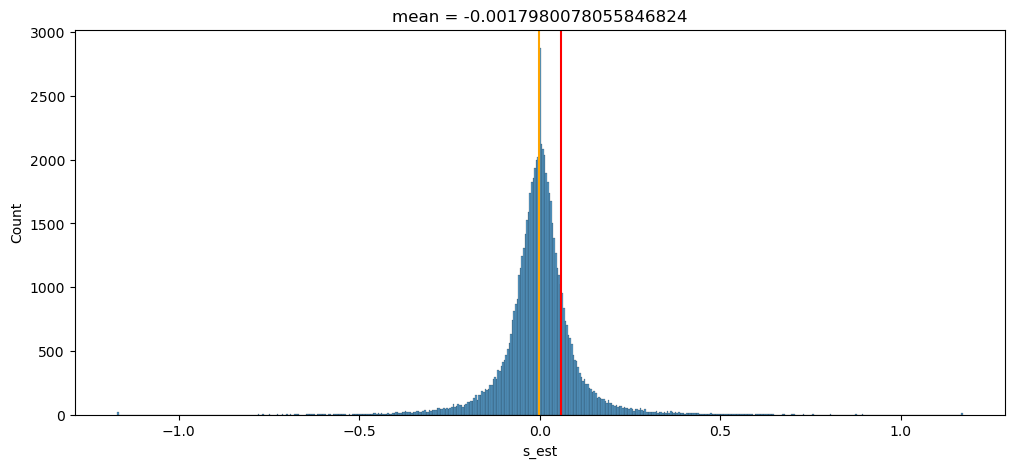

In [151]:
plt.figure(figsize=(12,5))
# sns.histplot(x=df[df.s_est.between(-0.6, 0.6)]['s_est'] + 1)
sns.histplot(x=df['s_est'] )
plt.axvline(x=0.059, color='red')
plt.axvline(x=df.s_est.mean(), color='orange')
plt.title(f"mean = {df.s_est.mean()}")

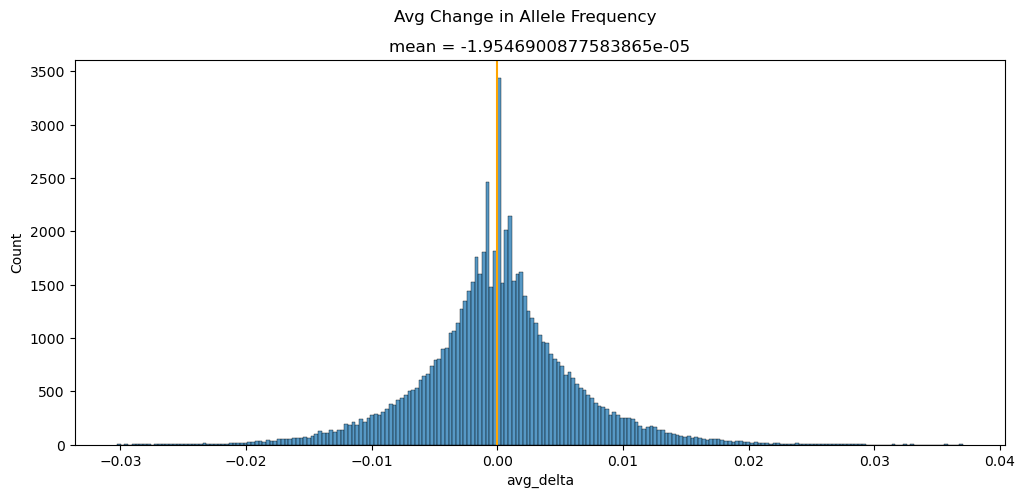

In [137]:
plt.figure(figsize=(12,5))
sns.histplot(x=df['avg_delta'])
plt.suptitle("Avg Change in Allele Frequency")
plt.title(f"mean = {df.avg_delta.mean()}")
plt.axvline(x=df.avg_delta.mean(), color='orange')
plt.show()

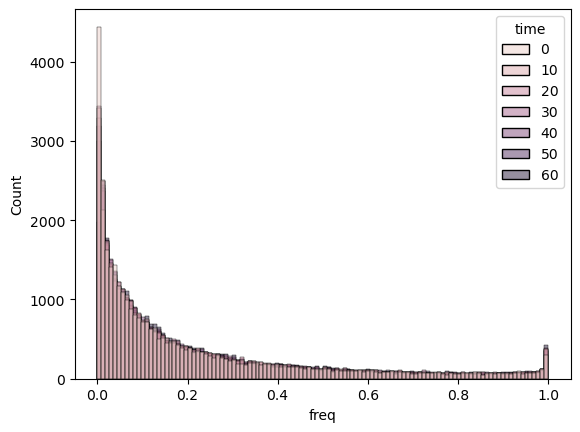

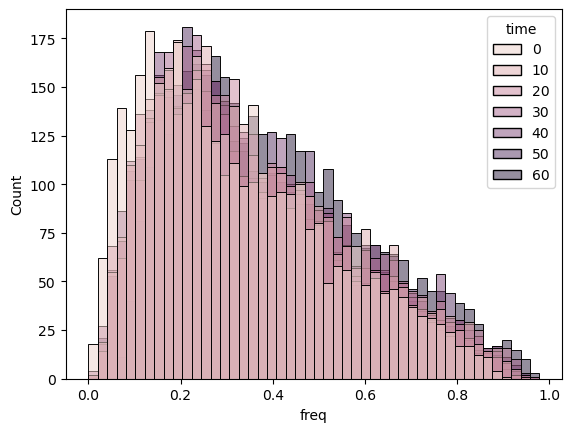

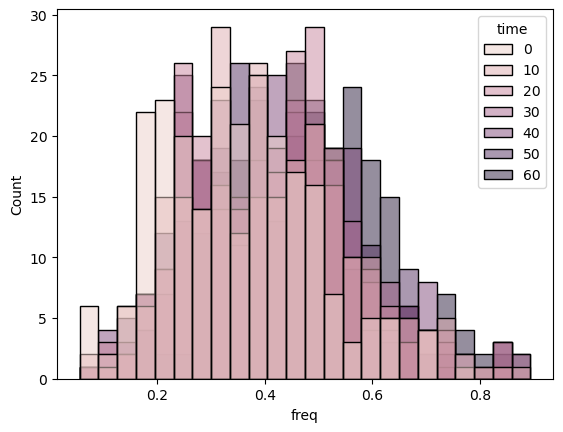

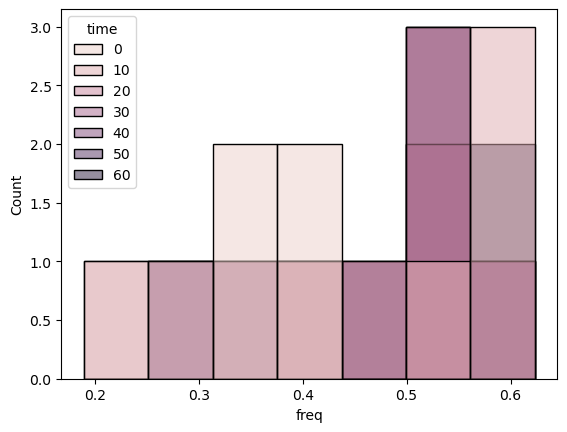

In [121]:
for boundary in [0, 0.01, 0.02, 0.03]:
    obs = df[df.avg_delta >= boundary][['position', 's_est', 'avg_freq', 'freq_t0', 'freq_t10', 'freq_t20', 'freq_t30', 'freq_t40', 'freq_t50', 'freq_t60']].melt(id_vars=['position', 'avg_freq', 's_est'], var_name='time', value_name='freq')
    obs['time'] = obs['time'].str.replace('freq_t', '').astype(int)
    
    sns.histplot(data=obs, x='freq', hue='time')
    plt.show()


    obs = df[df.avg_delta >= boundary][['position', 's_est', 'avg_freq', 'freq_t0', 'freq_t10', 'freq_t20', 'freq_t30', 'freq_t40', 'freq_t50', 'freq_t60']].melt(id_vars=['position', 'avg_freq', 's_est'], var_name='time', value_name='freq')